<a href="https://colab.research.google.com/github/ZethRodaje/Automata_Java_Activities/blob/main/phishing_website_detection_using_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phishing Website Detection Using Machine Learning - Initial Training**

**0. Setup and Config**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import re
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_STATE = 42
IP_RE = re.compile(r"^(\d{1,3}\.){3}\d{1,3}$")

**1. Load and Inspect**

In [ ]:
df = pd.read_csv("phishing_features.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (160064, 13)


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True) * 100)

Missing values:
url                     0
label                   0
url_length              0
num_dots                0
has_https               0
has_ip                  0
num_subdirs             0
num_params              0
suspicious_words        0
tld                   821
special_char_count      0
digits_count            0
entropy                 0
dtype: int64

Duplicate rows: 0

Label distribution:
label
1    159244
0       820
Name: count, dtype: int64
label
1    99.487705
0     0.512295
Name: proportion, dtype: float64


**2. Clean the Data**

In [ ]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Duplicates removed: {before - after} ({before} -> {after} rows)")

# 'tld' has a small number of missing values (URLs using a raw IP instead of a domain)
df["tld"] = df["tld"].fillna("unknown")
print("Remaining missing values:", df.isnull().sum().sum())

Duplicates removed: 0 (160064 -> 160064 rows)
Remaining missing values: 0


**3. Check for Data Leakage**

In [ ]:
numeric_features = ["url_length", "num_dots", "has_https", "has_ip", "num_subdirs",
                     "num_params", "suspicious_words", "special_char_count", "digits_count", "entropy"]

print("Feature correlation with label:")
print(df[numeric_features + ["label"]].corr()["label"].sort_values(key=abs, ascending=False))

print("\nChecking each feature for a perfectly-separating value range:")
for col in numeric_features:
    benign_vals = df.loc[df["label"] == 0, col]
    phishing_vals = df.loc[df["label"] == 1, col]
    if benign_vals.max() < phishing_vals.min() or phishing_vals.max() < benign_vals.min():
        print(f"  PERFECT SEPARATION on '{col}': benign [{benign_vals.min()}, {benign_vals.max()}], "
              f"phishing [{phishing_vals.min()}, {phishing_vals.max()}]")

Feature correlation with label:
label                 1.000000
num_subdirs           0.141735
entropy               0.133363
num_dots              0.125898
has_ip                0.069704
has_https             0.062848
digits_count          0.047991
url_length            0.028927
special_char_count    0.028911
num_params            0.016988
suspicious_words      0.008595
Name: label, dtype: float64

Checking each feature for a perfectly-separating value range:
  PERFECT SEPARATION on 'num_subdirs': benign [0, 0], phishing [2, 104]


**Digging deeper: why does num_subdirs show zero overlap?**

A feature being perfectly separable is a symptom -- worth checking *why* before just dropping it.

In [ ]:
print("Every benign URL has a scheme?", df.loc[df.label == 0, "url"].str.contains("://").any())
print("Every phishing URL has a scheme?", df.loc[df.label == 1, "url"].str.contains("://").all())
print()
print("num_subdirs by class:")
print(df.groupby("label")["num_subdirs"].describe()[["mean", "std", "min", "max"]])
print()
print("Sample benign URLs (note: bare domains, no scheme, no path):")
print(df.loc[df.label == 0, "url"].sample(8, random_state=1).tolist())

Every benign URL has a scheme? False
Every phishing URL has a scheme? True

num_subdirs by class:
           mean       std  min    max
label                                
0      0.000000  0.000000  0.0    0.0
1      4.149695  2.074399  2.0  104.0

Sample benign URLs (note: bare domains, no scheme, no path):
['shopify.com', 'trustedsite65.org', 'adobe.com', 'kaist.ac.kr', 'gov.cn', 'leetcode.com', 'atlassian.com', 'kaggle.com']


**Root cause found:** none of the 820 benign URLs carry a scheme (http:///https://) at all; they are bare domains like shopify.com, adobe.com, kaggle.com. That single collection artifact explains far more than just num_subdirs: has_https, num_params, and suspicious_words are not measuring phishing behavior for these rows, they are measuring which source list a URL came from (a full phishing feed URL vs. a bare-domain benign list). Any model trained on them gets a shortcut instead of a real signal, even for features that did not show up as "perfectly separating" in the simple range check above.

**3.5. Normalize URLs and Rebuild Features From the Host**

In [ ]:
def normalize_host(u):
    if "://" not in u:
        u = "http://" + u  # benign rows have no scheme; the scheme itself is never used as a feature
    return urlparse(u).netloc.split(":")[0]  # strip port, keep bare host

def shannon_entropy(s):
    if not s:
        return 0.0
    probs = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probs)

def get_tld(host):
    if IP_RE.match(host):
        return "ip_address"
    parts = host.split(".")
    return parts[-1] if len(parts) >= 2 else "unknown"

host = df["url"].map(normalize_host)
df["host"] = host
df["has_ip"] = host.str.match(IP_RE).astype(int)
df["tld"] = host.map(get_tld)
df["url_length"] = host.str.len()
df["num_dots"] = host.str.count(r"\.")
df["digits_count"] = host.str.count(r"\d")
df["special_char_count"] = host.str.count(r"[^a-zA-Z0-9\.\-]")
df["num_hyphens"] = host.str.count("-")
df["subdomain_count"] = host.apply(lambda s: max(len(s.split(".")) - 2, 0) if not IP_RE.match(s) else 0)
df["entropy"] = host.map(shannon_entropy)

# Dropped entirely: has_https (unmeasurable for benign source), num_subdirs / num_params /
# suspicious_words (path-only features; benign URLs have no path to measure)

feature_cols = ["url_length", "num_dots", "has_ip", "digits_count",
                 "special_char_count", "num_hyphens", "subdomain_count", "entropy"]

print("Feature means by class after normalization:")
print(df.groupby("label")[feature_cols].mean().T)

Feature means by class after normalization:
label                       0          1
url_length          14.078049  16.270849
num_dots             1.035366   2.381999
has_ip               0.000000   0.487296
digits_count         1.086585   5.994380
special_char_count   0.000000   0.002600
num_hyphens          0.004878   0.237773
subdomain_count      0.035366   0.407406
entropy              3.355376   3.015566


---

Compare this to the pre-normalization numbers: url_length for benign went from ~14 (bare domain) to still just a host measurement, no longer artificially short relative to a full phishing URL with a path. The remaining differences -- phishing hosts averaging more digits, more hyphens, and more subdomains; are genuine domain-naming patterns, not collection artifacts.

**3.6. Re-run the Leakage Check on the Normalized Features**

In [ ]:
print("Checking each normalized feature for a perfectly-separating value range:")
found = False
for col in feature_cols:
    benign_vals = df.loc[df["label"] == 0, col]
    phishing_vals = df.loc[df["label"] == 1, col]
    if benign_vals.max() < phishing_vals.min() or phishing_vals.max() < benign_vals.min():
        found = True
        print(f"  PERFECT SEPARATION on '{col}'")
if not found:
    print("  None found. Features now overlap between classes as expected.")

Checking each normalized feature for a perfectly-separating value range:
  None found. Features now overlap between classes as expected.


**4. Finalize the Feature Set**

In [ ]:
X = df[feature_cols + ["tld"]].copy()
y = df["label"]

print("Final input features (before tld encoding):", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())


Final input features (before tld encoding): ['url_length', 'num_dots', 'has_ip', 'digits_count', 'special_char_count', 'num_hyphens', 'subdomain_count', 'entropy', 'tld']

Target distribution:
label
1    159244
0       820
Name: count, dtype: int64


**5. Train/Test Split (Stratified)**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Fit tld frequency encoding on the TRAINING set only, then apply to both -- avoids leaking
# any test-set information into the encoding (a TLD's frequency must come from training data alone)
tld_freq_map = x_train["tld"].value_counts(normalize=True)
x_train = x_train.assign(tld_freq=x_train["tld"].map(tld_freq_map).fillna(0)).drop(columns=["tld"])
x_test = x_test.assign(tld_freq=x_test["tld"].map(tld_freq_map).fillna(0)).drop(columns=["tld"])

print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

Training set shape: (128051, 9)
Testing set shape: (32013, 9)


**6. Address the Class Imbalance**

In [ ]:
model_weighted = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE)
model_weighted.fit(x_train, y_train)

# Undersample the majority class to a 3:1 ratio, keeping only real data (no synthetic points)
rng = np.random.RandomState(RANDOM_STATE)
train_bal = x_train.copy()
train_bal["label"] = y_train.values

benign_tr = train_bal[train_bal["label"] == 0]
phishing_tr_full = train_bal[train_bal["label"] == 1]
phishing_tr = phishing_tr_full.sample(n=min(len(benign_tr) * 3, len(phishing_tr_full)), random_state=RANDOM_STATE)

train_bal = pd.concat([benign_tr, phishing_tr]).sample(frac=1, random_state=RANDOM_STATE)
x_train_bal = train_bal.drop(columns=["label"])
y_train_bal = train_bal["label"]

print("Undersampled training class balance:")
print(y_train_bal.value_counts())


Undersampled training class balance:
label
1    1968
0     656
Name: count, dtype: int64


**7. Train Random Forest (Two Sampling Strategies)**

In [ ]:
model_undersample_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE)
model_undersample_rf.fit(x_train_bal, y_train_bal)

print("All models trained: Random Forest (class weighting, full data), Random Forest (undersampled)")


All models trained: Random Forest (class weighting, full data), Random Forest (undersampled)


**8. Evaluate Both Random Forest Variants on the Same Test Set**

In [ ]:
def evaluate(name, model, x_eval, y_eval):
    preds = model.predict(x_eval)
    accuracy = accuracy_score(y_eval, preds)
    precision = precision_score(y_eval, preds, pos_label=1)
    recall = recall_score(y_eval, preds, pos_label=1)
    f1 = f1_score(y_eval, preds, pos_label=1)
    macro_f1 = f1_score(y_eval, preds, average="macro")

    cm = confusion_matrix(y_eval, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    benign_recall = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1 Score : {f1*100:.2f}%  (phishing class only; stays high regardless of benign performance)")
    print(f"Macro F1 : {macro_f1*100:.2f}%  (averages both classes equally; the fairer comparison metric)")
    print(f"False Positive Rate: {fpr*100:.2f}%")
    print(f"Benign Recall: {benign_recall*100:.2f}%")
    print(f"Confusion Matrix:\n{cm}")

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall,
            "F1 Score": f1, "Macro F1": macro_f1, "False Positive Rate": fpr,
            "Benign Recall": benign_recall}

results_weighted = evaluate("Random Forest (Class Weighting, full data)", model_weighted, x_test, y_test)
results_undersample_rf = evaluate("Random Forest (Undersampled)", model_undersample_rf, x_test, y_test)



=== Random Forest (Class Weighting, full data) ===
Accuracy : 98.77%
Precision: 99.88%
Recall   : 98.88%
F1 Score : 99.38%  (phishing class only; stays high regardless of benign performance)
Macro F1 : 69.29%  (averages both classes equally; the fairer comparison metric)
False Positive Rate: 22.56%
Benign Recall: 77.44%
Confusion Matrix:
[[  127    37]
 [  357 31492]]

=== Random Forest (Undersampled) ===
Accuracy : 97.54%
Precision: 99.96%
Recall   : 97.57%
F1 Score : 98.75%  (phishing class only; stays high regardless of benign performance)
Macro F1 : 63.25%  (averages both classes equally; the fairer comparison metric)
False Positive Rate: 7.93%
Benign Recall: 92.07%
Confusion Matrix:
[[  151    13]
 [  773 31076]]


**9. Compare the Two Random Forest Variants**

In [ ]:
comparison = pd.DataFrame({
    "Random Forest (Class Weighting, full data)": results_weighted,
    "Random Forest (Undersampled)": results_undersample_rf,
}).T.round(4)
comparison

,Accuracy,Precision,Recall,F1 Score,Macro F1,False Positive Rate,Benign Recall
"Random Forest (Class Weighting, full data)",0.9877,0.9988,0.9888,0.9938,0.6929,0.2256,0.7744
Random Forest (Undersampled),0.9754,0.9996,0.9757,0.9875,0.6325,0.0793,0.9207


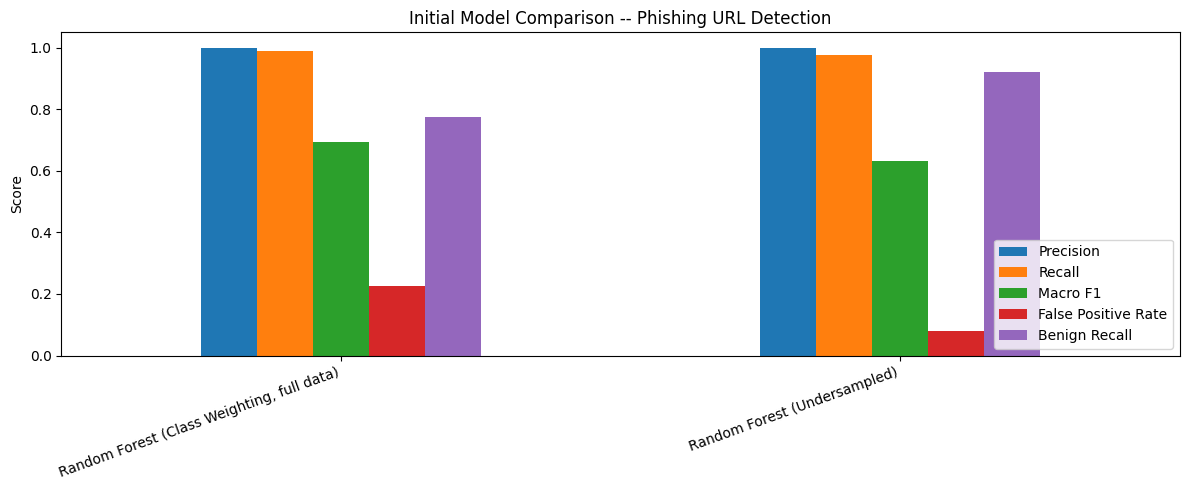

Leading candidate (by Macro F1): Random Forest (Class Weighting, full data)
Macro F1 is used here instead of F1 (phishing-only), since F1 alone can stay high
even when a model performs poorly on the rare benign class.


In [ ]:
comparison[["Precision", "Recall", "Macro F1", "False Positive Rate", "Benign Recall"]].plot(kind="bar", figsize=(12, 5))
plt.title("Initial Model Comparison -- Phishing URL Detection")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

leading = comparison["Macro F1"].idxmax()
print(f"Leading candidate (by Macro F1): {leading}")
print("Macro F1 is used here instead of F1 (phishing-only), since F1 alone can stay high")
print("even when a model performs poorly on the rare benign class.")

**10. Confusion Matrix Visualization (Leading Candidate)**

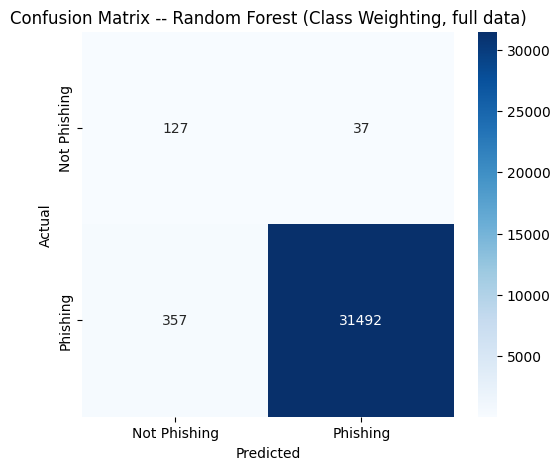

In [ ]:
leading_model_map = {
    "Random Forest (Class Weighting, full data)": (model_weighted, x_test),
    "Random Forest (Undersampled)": (model_undersample_rf, x_test),
}
best_model, best_x = leading_model_map[leading]
preds = best_model.predict(best_x)
cm = confusion_matrix(y_test, preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Phishing", "Phishing"], yticklabels=["Not Phishing", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix -- {leading}")
plt.show()

**11. Cross-Validation (Check Result Stability)**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_cv = X.assign(tld_freq=X["tld"].map(X["tld"].value_counts(normalize=True))).drop(columns=["tld"])
cv_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_model, X_cv, y, cv=cv, scoring="f1_macro")

print("5-Fold Cross-Validation Macro F1 scores:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean()*100:.2f}%  (+/- {cv_scores.std()*100:.2f}%)")
print("\nA small standard deviation here means the result is stable across different splits, not just a lucky or unlucky one.")


5-Fold Cross-Validation Macro F1 scores: [0.6911 0.6882 0.678  0.6987 0.6988]
Mean: 69.10%  (+/- 0.77%)

A small standard deviation here means the result is stable across different splits, not just a lucky or unlucky one.


**12. Feature Importance (Leading Model)**

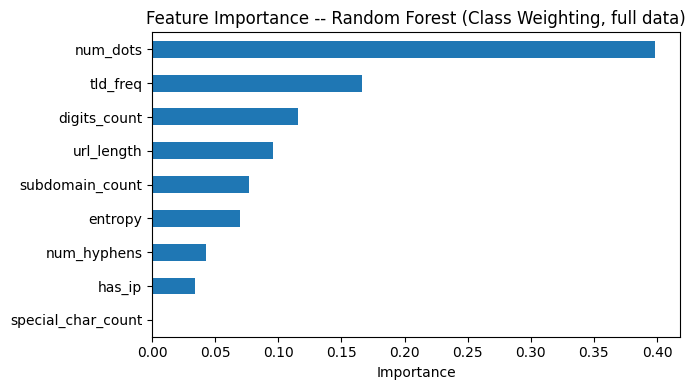

,0
num_dots,3.983418e-01
tld_freq,1.663716e-01
digits_count,1.156954e-01
url_length,9.582199e-02
subdomain_count,7.690486e-02
entropy,6.980242e-02
num_hyphens,4.301097e-02
has_ip,3.405032e-02
special_char_count,6.121988e-07


In [ ]:
importances = pd.Series(model_weighted.feature_importances_, index=x_train.columns).sort_values(ascending=False)

importances.plot(kind="barh", figsize=(7, 4))
plt.gca().invert_yaxis()
plt.title(f"Feature Importance -- {leading}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances